In [1]:
from qiskit import QuantumRegister, QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

In [3]:
a = QuantumRegister(3, "a")
qc = QuantumCircuit(a)

In [4]:
import numpy as np

In [5]:
qc.ry(np.pi / 3, a[0])
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "a"), index=0>, <Qubit register=(3, "a"), index=1>, <Qubit register=(3, "a"), index=2>), clbits=())

In [6]:
qc.cx(a[0], a[1])
qc.cx(a[0], a[2])

In [7]:
state = Statevector.from_instruction(qc)

In [8]:
state.draw('latex')

<IPython.core.display.Latex object>

/Users/demouser/.local/share/virtualenvs/qiskit-playground-xSEsUWdl/lib/python3.14/site-packages/qiskit/visualization/circuit/matplotlib.py:272: UserWarning: Style JSON file 'default.json' not found in any of these locations: /Users/demouser/.local/share/virtualenvs/qiskit-playground-xSEsUWdl/lib/python3.14/site-packages/qiskit/visualization/circuit/styles/default.json, ~/default.json, ~/.qiskit/default.json, default.json. Will use default style.
  self._style, def_font_ratio = load_style(


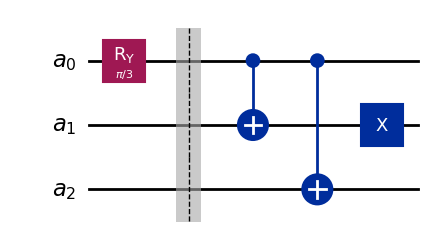

In [9]:
qc.x(a[1])
qc.draw('mpl')

In [10]:
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "a"), index=0>, <Qubit register=(3, "a"), index=1>, <Qubit register=(3, "a"), index=2>), clbits=())

In [11]:
Statevector.from_instruction(qc).draw('latex')

<IPython.core.display.Latex object>

In [42]:
ancilla = QuantumRegister(2, "ancilla")
from qiskit import ClassicalRegister
c = ClassicalRegister(3, "c")
code = QuantumCircuit(a, ancilla, c) 

In [43]:
code.ry(np.pi/3, a[0])
code.barrier()
code.cx(a[0], a[1])
code.cx(a[0], a[2])
code.barrier()
code.x(a[1])
code.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "a"), index=0>, <Qubit register=(3, "a"), index=1>, <Qubit register=(3, "a"), index=2>, <Qubit register=(2, "ancilla"), index=0>, <Qubit register=(2, "ancilla"), index=1>), clbits=())

In [44]:
code.cx(a[0], ancilla[0])
code.cx(a[1], ancilla[0])
code.cx(a[1], ancilla[1])
code.cx(a[2], ancilla[1])
code.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "a"), index=0>, <Qubit register=(3, "a"), index=1>, <Qubit register=(3, "a"), index=2>, <Qubit register=(2, "ancilla"), index=0>, <Qubit register=(2, "ancilla"), index=1>), clbits=())

In [45]:
code.x(ancilla[1])
code.ccx(ancilla[0], ancilla[1], a[0])
code.x(ancilla[1])

code.ccx(ancilla[0], ancilla[1], a[1])

code.x(ancilla[0])
code.ccx(ancilla[0], ancilla[1], a[2])
code.x(ancilla[0])

code.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "a"), index=0>, <Qubit register=(3, "a"), index=1>, <Qubit register=(3, "a"), index=2>, <Qubit register=(2, "ancilla"), index=0>, <Qubit register=(2, "ancilla"), index=1>), clbits=())

/Users/demouser/.local/share/virtualenvs/qiskit-playground-xSEsUWdl/lib/python3.14/site-packages/qiskit/visualization/circuit/matplotlib.py:272: UserWarning: Style JSON file 'default.json' not found in any of these locations: /Users/demouser/.local/share/virtualenvs/qiskit-playground-xSEsUWdl/lib/python3.14/site-packages/qiskit/visualization/circuit/styles/default.json, ~/default.json, ~/.qiskit/default.json, default.json. Will use default style.
  self._style, def_font_ratio = load_style(


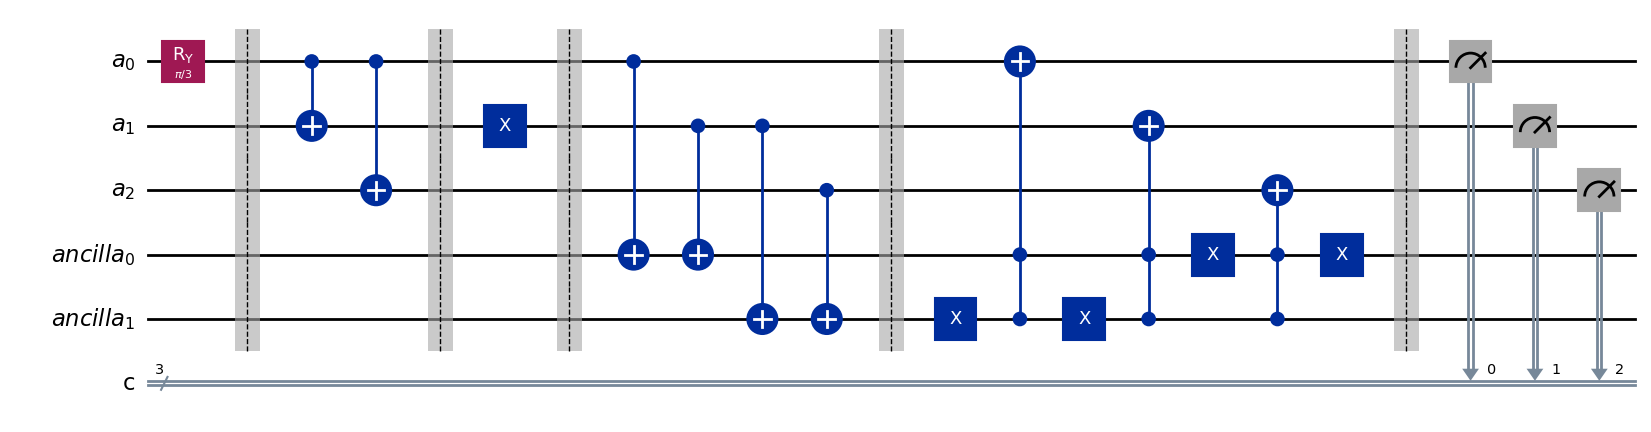

In [46]:
code.measure(a, c)
code.draw('mpl')

In [48]:
service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True, min_num_qubits=7)

In [49]:
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_qc = pm.run(code)
sampler = Sampler(mode=backend)

In [50]:
result = sampler.run([isa_qc]).result()

In [51]:
data = result[0].data
data

DataBin(c=BitArray(<shape=(), num_shots=4096, num_bits=3>))

In [53]:
data.keys()

dict_keys(['c'])

In [54]:
data['c'].get_counts()

{'000': 2581,
 '111': 808,
 '110': 154,
 '100': 92,
 '011': 93,
 '010': 196,
 '101': 68,
 '001': 104}

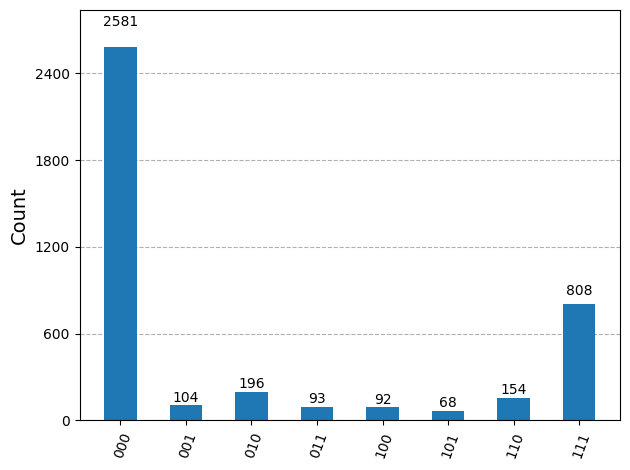

In [55]:
plot_histogram(data['c'].get_counts())